## Imports

# Stage 0 & 1: Data Inspection and Sparse Autoencoder

## Overview
This notebook combines two critical stages of the sparse neural network pipeline:
1. **Stage 0 - Data Inspection**: Explore dataset structure and understand the sparsity of jet tensors
2. **Stage 1 - Sparse Autoencoder**: Train first encoder-decoder on unlabeled data for self-supervised learning

## Pipeline Context
```
Stage 0: Inspect data structure
    ↓
Stage 1: Train Encoder1 + Decoder1 (unsupervised, unlabeled data)
    ↓
Stage 2: Refine latent representations with Encoder2
    ↓
Stage 3: Fine-tune classifier head (supervised, labeled data)
    ↓
Stage 4: Evaluate and analyze efficiency (FLOPs vs accuracy)
```

## Key Concepts

### Data Format
- **Input**: Jet tensor of shape (125, 125, 8) representing particle detector readings
- **Sparsity**: ~90% of values are zero; only ~1000-2000 active spatial sites per sample
- **Format Conversion**: Dense (H,W,C) → Sparse coordinate-feature pairs for efficient computation

### Stage 1 Objective
Train an autoencoder to reconstruct jet tensors from sparse representations. This learns:
- Hierarchical feature extraction at multiple scales
- Compression: 125x125x8 → 32 latent dims → 125x125x8 reconstruction
- Loss: Weighted MSE with higher weight on non-zero values

### Why Sparse Convolutions Matter
- **Standard CNN**: Would compute on all 125×125=15,625 spatial locations per sample
- **Sparse VSC**: Only computes on ~1000 active sites → ~10x speedup
- **Benefit**: Massive computational savings without losing information

In [ ]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from utility import *
from models_arch import *
from torch import optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Dataset Inspection 

## Part 1: Dataset Inspection

This section explores the structure of both labeled and unlabeled datasets:
- Dataset dimensions and types
- HDF5 file structure
- Sparsity characteristics (percentage of zero values)

We use the unlabeled dataset (60,000 samples) for Stage 1 training.

In [2]:
UNLAB_PATH = "data/Dataset_Specific_Unlabelled.h5"
LAB_PATH   = "data/Dataset_Specific_labelled.h5"

def inspect_h5(path):
    print(f"\n inspecting {path} ____:")
    with h5py.File(path, "r") as f:
        def walk(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"[DATASET] {name}  shape={obj.shape}  dtype={obj.dtype}")
            elif isinstance(obj, h5py.Group):
                print(f"[GROUP]   {name}")
        f.visititems(walk)

        print("\n-- File attributes --")
        for k, v in f.attrs.items():
            print(k, v)

inspect_h5(UNLAB_PATH)
inspect_h5(LAB_PATH)


 inspecting data/Dataset_Specific_Unlabelled.h5 ____:
[DATASET] jet  shape=(60000, 125, 125, 8)  dtype=float32

-- File attributes --

 inspecting data/Dataset_Specific_labelled.h5 ____:
[DATASET] Y  shape=(10000, 1)  dtype=float32
[DATASET] jet  shape=(10000, 125, 125, 8)  dtype=float32

-- File attributes --


In [4]:
class H5UnlabelledDataset(Dataset):
    def __init__(self, h5_path, x_key):
        self.h5_path = h5_path
        self.x_key = x_key

        # Read length once (no persistent open handle here)
        with h5py.File(self.h5_path, "r") as f:
            self.length = f[self.x_key].shape[0]

        # Open lazily per-worker/process
        self._f = None
        self._x = None

    def _ensure_open(self):
        if self._f is None:
            self._f = h5py.File(self.h5_path, "r")
            self._x = self._f[self.x_key]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        self._ensure_open()
        x = self._x[idx]  # numpy array
        x = torch.from_numpy(x)  # torch tensor (dtype preserved)
        return x

In [5]:
X_KEY = "jet" 

ds = H5UnlabelledDataset(UNLAB_PATH, X_KEY)
dl = DataLoader(ds, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)

batch = next(iter(dl))
print("batch shape:", batch.shape, "dtype:", batch.dtype)
print("nonzeros in batch[0]:", int((batch[0] != 0).sum())) # We need to check how sparse the data is!   

batch shape: torch.Size([4, 125, 125, 8]) dtype: torch.float32
nonzeros in batch[0]: 1278


## Moving the dataset into the sparse format 
we have each data sample as a dense tensor of shape (H, W, C). 

We are going to convert this into a sparse format where we only store the non-zero entries. with the following format:

1- Coords: Store the coordinates of the non-zero entries into a tensor of shape (N,2) where N is the number of non-zero entries. Each row contains the (h,w) coordinates of a non-zero entry.

2- Features: Store the corresponding feature values of the non-zero entries into a tensor of shape (N,C) where each row contains the C feature values for the corresponding non-zero entry.

## Part 2: Sparse Format Conversion

Core abstraction for efficient sparse operations:

**Input Format (Dense)**:
- Shape: (125, 125, 8) - height, width, channels
- Mostly zero values (~90% sparsity)

**Output Format (Sparse)**:
- **Coordinates**: (N, 2) tensor [y, x] - N is number of active sites
- **Features**: (N, 8) tensor - feature values at each active location

**Sparse Collation**:
When batching multiple samples:
- Prepend batch index to coordinates: [y, x] → [batch_id, y, x]
- Concatenate all coordinates and features
- Result: coordinates shape (N_total, 3), features shape (N_total, 8)

**Why this matters**:
- Reduces storage from 125×125×8 = 125,000 floats to ~1,000×8 ≈ 8,000 floats
- Computation only happens at active sites, not on zeros
- Rulebook pre-computation maps sparse convolution operations

In [6]:
# Let's test the conversion on a single sample
x0 = ds[0]           
coords, feats = to_sparse_hwC(x0)
print("x0 shape:", x0.shape)
print("coords:", coords.shape, coords.dtype) # number of active spatial sites (N) and their data type
print("feats:", feats.shape, feats.dtype)  # number of channels (C) for each active site and their data type
print("active spatial sites:", coords.shape[0]) 

# Since we have 1845 nonzero value and 1143 active spatial sites, this means that on average each active site has about 1 or 2 nonzero features.

x0 shape: torch.Size([125, 125, 8])
coords: torch.Size([1143, 2]) torch.int64
feats: torch.Size([1143, 8]) torch.float32
active spatial sites: 1143


In [6]:
dl_sparse = DataLoader(
    ds,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    collate_fn=sparse_collate_hwC,
    pin_memory=True
)

coords, feats, sizes = next(iter(dl_sparse))
print("coords:", coords.shape, coords.dtype)  # (N_total, 3) long [b,y,x]
print("feats:", feats.shape, feats.dtype)    # (N_total, 8)
print("first 3 sizes:", sizes[:3], "sum:", sum(sizes))
print("first coord row:", coords[0].tolist())

coords: torch.Size([9228, 3]) torch.int64
feats: torch.Size([9228, 8]) torch.float32
first 3 sizes: [1211, 1265, 1082] sum: 9228
first coord row: [0, 1, 18]


In [8]:
coords, feats, sizes = next(iter(dl_sparse))

coords = coords.cpu()
feats = feats.float()

rules = build_vsc_rulebook(coords)

block = SparseVSCBlockRulebook(8, 16)
coords_out, feats_out = block(coords, feats, rules)

print("coords_out:", coords_out.shape)
print("feats_out:", feats_out.shape)

coords_out: torch.Size([9851, 3])
feats_out: torch.Size([9851, 16])


## Part 3: Sparse Encoder Architecture

**Encoder1** implements a hierarchical VGG-style architecture:

```
Input: coordinates (N,3), features (N,8)
    ↓
Stage1: 3× [VSC 3×3 (8→16) + BatchNorm + ReLU] + Max Pool 2×2
    ↓ (downsampled ~4x)
Stage2: 2× [VSC 3×3 (16→32) + BatchNorm + ReLU] + Max Pool 2×2
    ↓ (downsampled ~4x)
Output: coordinates (M,3), features (M,32)  [M ≈ N/16 sites remain]
```

**Key Components**:
- **VSC (Rulebook Sparse Convolution)**: 3×3 kernel, operates only on active neighbors
- **Batch Normalization**: Applied per feature across active sites
- **Max Pooling**: Spatial downsampling via coordinate division and feature aggregation
- **Hierarchical channels**: 8 → 16 → 32 (increasing receptive field and abstraction)

**Efficiency Gain**:
- Dense CONV: 125×125 spatial locs × 8→16 channels = expensive
- Sparse CONV: ~1000 active sites × 8→16 channels = ~12x faster

In [26]:
coords, feats, sizes = next(iter(dl_sparse))

coords = coords.cpu()
feats = feats.float()

enc1 = Encoder1()
coords1, z1 = enc1(coords, feats)

print("Encoder1 final coords:", coords1.shape)
print("Encoder1 final latent:", z1.shape)

Encoder1 input: torch.Size([10993, 3]) torch.Size([10993, 8])
After stage1: torch.Size([5551, 3]) torch.Size([5551, 16])
After stage2: torch.Size([3251, 3]) torch.Size([3251, 32])
Encoder1 final coords: torch.Size([3251, 3])
Encoder1 final latent: torch.Size([3251, 32])


In [ ]:
def weighted_mse_loss(x_hat, x, pos_weight=10.0):
    mask = (x != 0).float()
    weights = 1.0 + (pos_weight - 1.0) * mask
    return ((weights * (x_hat - x) ** 2).mean())

In [ ]:
ae1 = AutoEncoder1().to(device)
optimizer = optim.Adam(ae1.parameters(), lr=1e-3)
def train_ae1_one_epoch(model, loader, optimizer, device, pos_weight=10.0, max_batches=None, accum_steps=2):
    model.train()
    total_loss = 0.0
    total_batches = 0

    optimizer.zero_grad()

    for batch_idx, dense_batch in enumerate(loader):
        dense_batch = dense_batch.float()

        coords, feats, sizes = sparse_collate_hwC(dense_batch)

        dense_batch = dense_batch.to(device, non_blocking=True)
        coords = coords.to(device, non_blocking=True)
        feats = feats.to(device, non_blocking=True)

        x_hat, coords1, z1, z_global = model(coords, feats, batch_size=dense_batch.shape[0])

        raw_loss = weighted_mse_loss(x_hat, dense_batch, pos_weight=pos_weight)
        loss = raw_loss / accum_steps
        loss.backward()

        if (batch_idx + 1) % accum_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        total_loss += raw_loss.item()
        total_batches += 1

        if batch_idx % 100 == 0:
            print(f"batch {batch_idx}: loss = {raw_loss.item():.6f}")

        if max_batches is not None and batch_idx + 1 >= max_batches:
            break

    if total_batches % accum_steps != 0:
        optimizer.step()
        optimizer.zero_grad()

    return total_loss / max(total_batches, 1)

## Part 4: AutoEncoder1 Training

**Architecture**:
- Encoder: Hierarchical sparse convolution (8→16→32 channels)
- Global pooling: Mean aggregate over active sites to get (B,32) batch vectors
- Decoder: 3-layer MLP (32→256→256→125000) → reshape to (B,125,125,8)

**Reconstruction Loss - Weighted MSE**:
```
loss = mean((x_hat - x)^2 * weights)
weights = 1 + (pos_weight - 1) * mask
```
where `mask=1` at non-zero locations, `mask=0` elsewhere, and `pos_weight=10`.

**Why weighted loss?**
- Non-zero values carry signal; zero values are mostly background
- Weighting non-zeros 10x more encourages accurate reconstruction
- Prevents decoder from learning to output all zeros

**Training Strategy**:
- **Optimizer**: Adam (lr=1e-3)
- **Batch size**: 8 samples
- **Gradient accumulation**: Accumulate 2 basches before step (effective bs=16)
- **Epochs**: 30 (full training on 60,000 unlabeled samples)
- **Data loading**: 2 workers, pinned memory for GPU transfer

**Output**:
- Saves best encoder (encoder1) weights for Stage 2
- Latent: (B, 32) vectors capture learned representations
- Next: Use this encoder to process unlabeled data and create latent dataset

In [102]:
epoch_losses = []

for epoch in range(30):
    avg_loss = train_ae1_one_epoch(
        ae1,
        dl,
        optimizer,
        device,
        pos_weight=10.0,
        max_batches= 1000
    )

    epoch_losses.append(avg_loss)
    print(f"epoch {epoch}: avg_loss = {avg_loss:.6f}")

batch 0: loss = 716.968018
batch 100: loss = 811.659546
batch 200: loss = 589.179138
batch 300: loss = 875.305420
batch 400: loss = 834.230957
batch 500: loss = 711.113831
batch 600: loss = 737.361938
batch 700: loss = 548.240173
batch 800: loss = 745.832764
batch 900: loss = 503.082550
epoch 0: avg_loss = 658.956682
batch 0: loss = 551.093140
batch 100: loss = 492.761719
batch 200: loss = 565.763855
batch 300: loss = 696.667969
batch 400: loss = 835.251892
batch 500: loss = 554.936340
batch 600: loss = 664.217529
batch 700: loss = 668.441956
batch 800: loss = 621.555481
batch 900: loss = 598.602173
epoch 1: avg_loss = 635.142809
batch 0: loss = 640.651367
batch 100: loss = 682.638306
batch 200: loss = 576.876770
batch 300: loss = 653.516724
batch 400: loss = 475.141846
batch 500: loss = 708.144592
batch 600: loss = 959.941223
batch 700: loss = 681.576294
batch 800: loss = 823.484985
batch 900: loss = 683.780090
epoch 2: avg_loss = 629.721292
batch 0: loss = 717.894897
batch 100: loss 

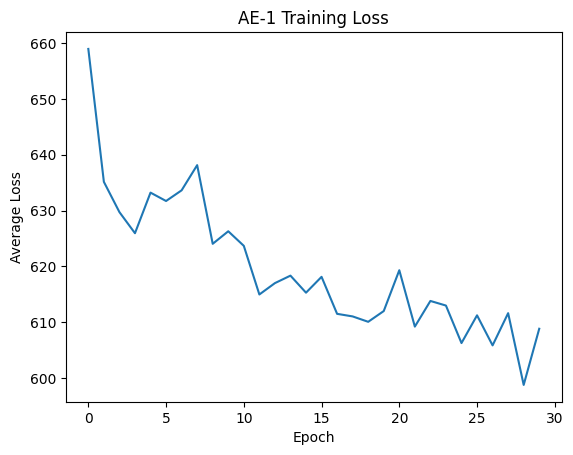

In [ ]:
import matplotlib.pyplot as plt

plt.plot(epoch_losses)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("AE-1 Training Loss")
plt.show()
torch.save(ae1.state_dict(), "ae1_trained.pth")
print("AE1 saved.")

ae1 = torch.load("ae1_trained.pth")

In [ ]:
ae1 = AutoEncoder1()
ae1.load_state_dict(torch.load("ae1_trained.pth", map_location=device))
ae1 = ae1.to(device)

print("AE1 loaded successfully")

/tmp/ipykernel_37541/3883717702.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ae1.load_state_dict(torch.load("ae1_trained.pth", map_location=device))


AE1 loaded successfully


In [34]:
encoder1 = ae1.encoder
encoder1.eval()

for p in encoder1.parameters():
    p.requires_grad = False

print("Encoder1 frozen.")

Encoder1 frozen.


In [41]:
import h5py

out_path = "data/latent.h5"

with h5py.File(out_path, "a") as f:
    if "coords" not in f:
        f.create_dataset(
            "coords",
            shape=(0, 3),
            maxshape=(None, 3),
            dtype="int64",
            chunks=True
        )
    if "feats" not in f:
        f.create_dataset(
            "feats",
            shape=(0, 32),
            maxshape=(None, 32),
            dtype="float32",
            chunks=True
        )
    if "sizes" not in f:
        f.create_dataset(
            "sizes",
            shape=(0,),
            maxshape=(None,),
            dtype="int64",
            chunks=True
        )

    print("keys after init:", list(f.keys()))

keys after init: ['coords', 'feats', 'sizes']


In [42]:
encoder1.eval()
out_path = "data/latent.h5"

with h5py.File(out_path, "a") as f, torch.no_grad():
    coords_ds = f["coords"]
    feats_ds = f["feats"]
    sizes_ds = f["sizes"]

    coord_offset = coords_ds.shape[0]
    size_offset = sizes_ds.shape[0]

    for batch_idx, dense_batch in enumerate(dl):
        dense_batch = dense_batch.float()

        coords, feats, _ = sparse_collate_hwC(dense_batch)

        coords = coords.to(device, non_blocking=True)
        feats = feats.to(device, non_blocking=True)

        coords1, z1 = encoder1(coords, feats)

        coords1_cpu = coords1.cpu().numpy()
        z1_cpu = z1.cpu().numpy()

        latent_batch_sizes = (
            torch.bincount(coords1[:, 0].cpu(), minlength=dense_batch.shape[0])
            .numpy()
            .astype("int64")
        )

        old_coord_offset = coord_offset
        coord_offset += coords1_cpu.shape[0]

        coords_ds.resize((coord_offset, 3))
        coords_ds[old_coord_offset:coord_offset] = coords1_cpu

        feats_ds.resize((coord_offset, 32))
        feats_ds[old_coord_offset:coord_offset] = z1_cpu

        old_size_offset = size_offset
        size_offset += len(latent_batch_sizes)

        sizes_ds.resize((size_offset,))
        sizes_ds[old_size_offset:size_offset] = latent_batch_sizes

        if batch_idx % 50 == 0:
            print(f"processed batch {batch_idx} | coords stored: {coord_offset} | samples stored: {size_offset}")

print("Latent dataset saved.")

processed batch 0 | coords stored: 1623 | samples stored: 4
processed batch 50 | coords stored: 84134 | samples stored: 204
processed batch 100 | coords stored: 163752 | samples stored: 404
processed batch 150 | coords stored: 246115 | samples stored: 604
processed batch 200 | coords stored: 327714 | samples stored: 804
processed batch 250 | coords stored: 407844 | samples stored: 1004
processed batch 300 | coords stored: 488673 | samples stored: 1204
processed batch 350 | coords stored: 569388 | samples stored: 1404
processed batch 400 | coords stored: 652023 | samples stored: 1604
processed batch 450 | coords stored: 736831 | samples stored: 1804
processed batch 500 | coords stored: 821682 | samples stored: 2004
processed batch 550 | coords stored: 904281 | samples stored: 2204
processed batch 600 | coords stored: 987484 | samples stored: 2404
processed batch 650 | coords stored: 1071981 | samples stored: 2604
processed batch 700 | coords stored: 1151062 | samples stored: 2804
proces